In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import yaml

data = {
    'train': '/kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/train/images',
    'val': '/kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/valid/images',
    'test': '/kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images',
    'nc': 5,
    'names': ['cauliflower_bacterial _spot _rot','cauliflower_downy_mildew','cauliflower_downy_mildew','cauliflower_healthy','chilli_whitefly']
}

yaml_path = "/kaggle/working/data.yaml"

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("YAML file created successfully!")

YAML file created successfully!


In [4]:
model = YOLO("yolov8n.pt")

In [5]:
model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="plant_disease_minority"
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plant_disease_minority, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e86e0c8e210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [6]:
!ls /kaggle/working/runs/detect/

plant_disease_minority


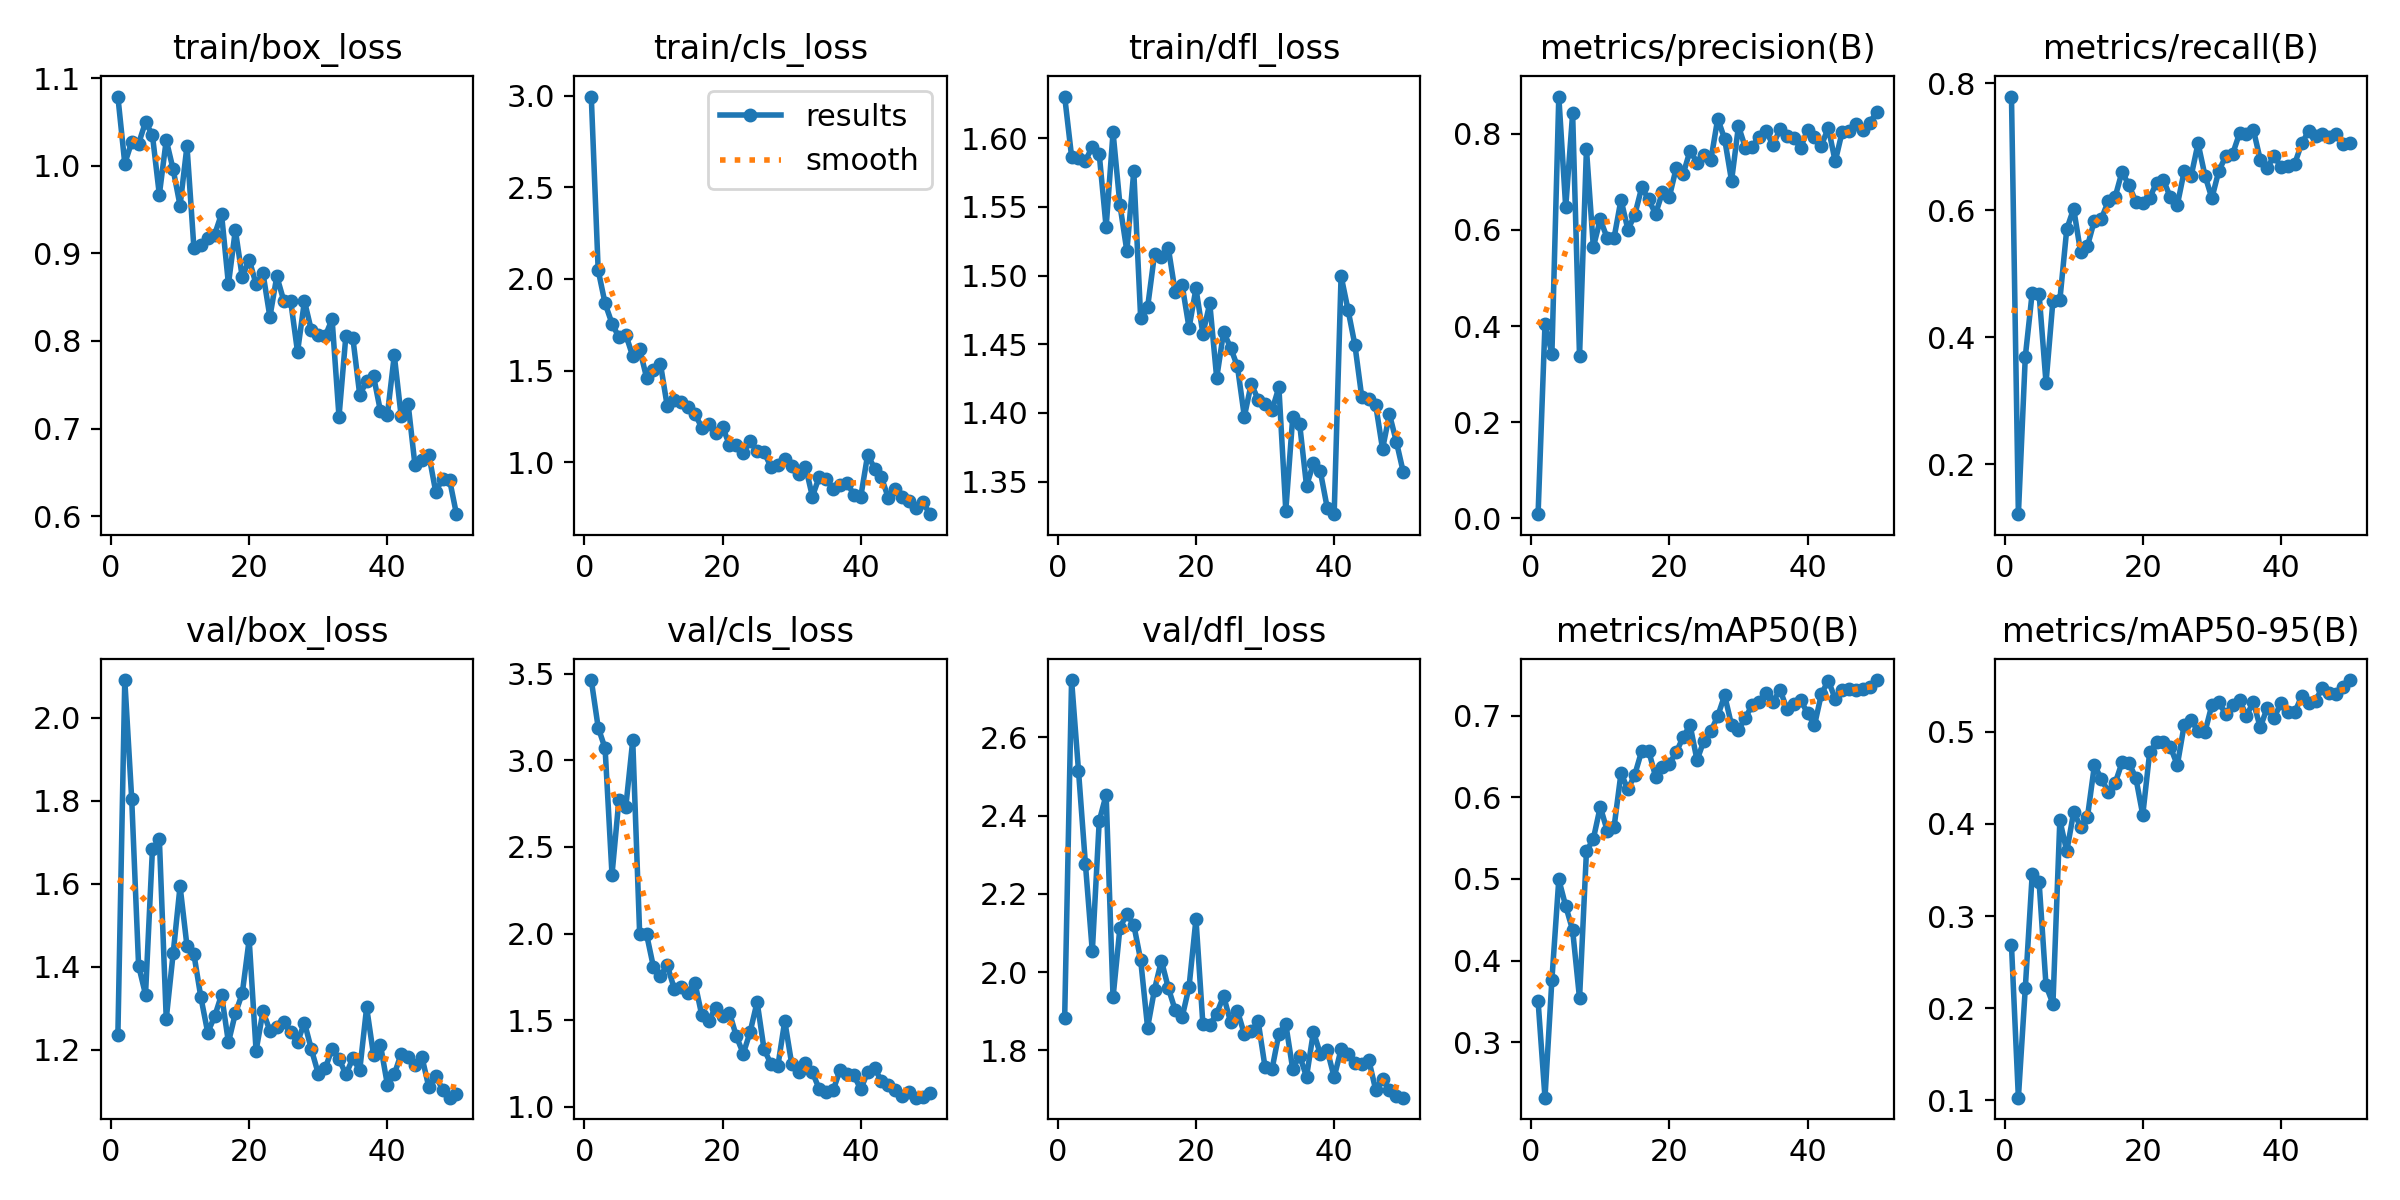

In [7]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/plant_disease_minority/results.png")

In [8]:
model = YOLO("/kaggle/working/runs/detect/plant_disease_minority/weights/best.pt")

results = model.predict(
    source="/kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images",
    save=True
)


image 1/67 /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images/Bacterial-Spot_-152-_jpg.rf.5ded6f3547e4391ea0c27e733c702b2b.jpg: 640x640 1 cauliflower_bacterial _spot _rot, 6.2ms
image 2/67 /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images/Bacterial-Spot_-153-_jpg.rf.e612cb081dee72b196f364399dbba53a.jpg: 640x640 2 cauliflower_bacterial _spot _rots, 6.2ms
image 3/67 /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images/Bacterial-Spot_-155-_jpg.rf.b42b91117a563470666eb13108dfbe7a.jpg: 640x640 1 cauliflower_bacterial _spot _rot, 6.0ms
image 4/67 /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images/Bacterial-Spot_-156-_jpg.rf.4d8f111266c210acc2225c437f2520de.jpg: 640x640 1 cauliflower_bacterial _spot _rot, 6.1ms
image 5/67 /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/test/images/Bacterial-Spot_-157-_jpg.rf.e390cd9786388055488bfe2b25d3b76e.jpg: 640x640 1 cauliflo

In [9]:
!ls /kaggle/working/runs/detect/predict

Bacterial-Spot_-152-_jpg.rf.5ded6f3547e4391ea0c27e733c702b2b.jpg
Bacterial-Spot_-153-_jpg.rf.e612cb081dee72b196f364399dbba53a.jpg
Bacterial-Spot_-155-_jpg.rf.b42b91117a563470666eb13108dfbe7a.jpg
Bacterial-Spot_-156-_jpg.rf.4d8f111266c210acc2225c437f2520de.jpg
Bacterial-Spot_-157-_jpg.rf.e390cd9786388055488bfe2b25d3b76e.jpg
Bacterial-Spot_-158-_jpg.rf.3fc69a0a1b9a969a91fb9024e1e4a92a.jpg
Bacterial-Spot_-159-_jpg.rf.4326d6d58574788c44dabf79ea77cfe9.jpg
Bacterial-Spot_-160-_jpg.rf.b7667bb83edd11a1f2b9148895ef1460.jpg
Bacterial-Spot_-161-_jpg.rf.4fde1901e556c5b760d65fed412690d4.jpg
Bacterial-Spot_-163-_jpg.rf.87f59a57c0abca82709d26de36d08706.jpg
Bacterial-Spot_-164-_jpg.rf.6c88a057d4e3829ec37b7c77b59086d7.jpg
Bacterial-Spot_-165-_jpg.rf.bf519c3b82094c7a2e2756a152cdc83d.jpg
Bacterial-Spot_-166-_jpg.rf.fab628bc978a5ca3988580c91d7a2e14.jpg
Bacterial-Spot_-167-_jpg.rf.818b6a6235d0704662a7ca3dff22d771.jpg
Bacterial-Spot_-170-_jpg.rf.87373f0bebe259b1ecb5451a06100523.jpg
Bacterial-Spot_-173-_jpg.


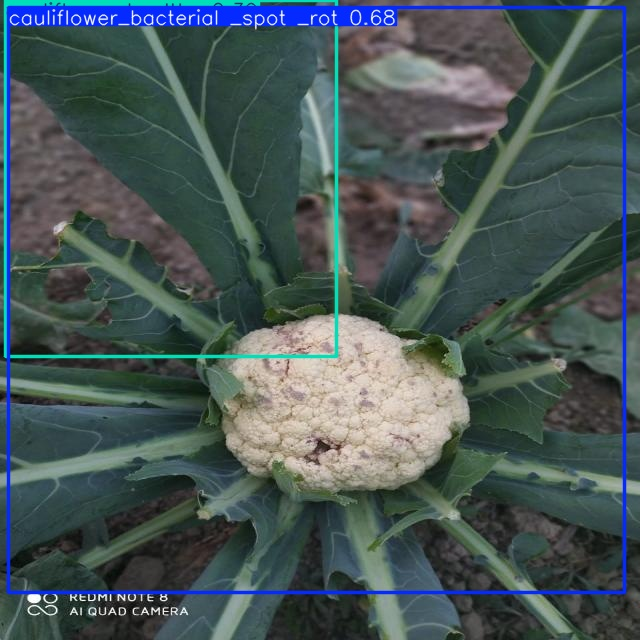
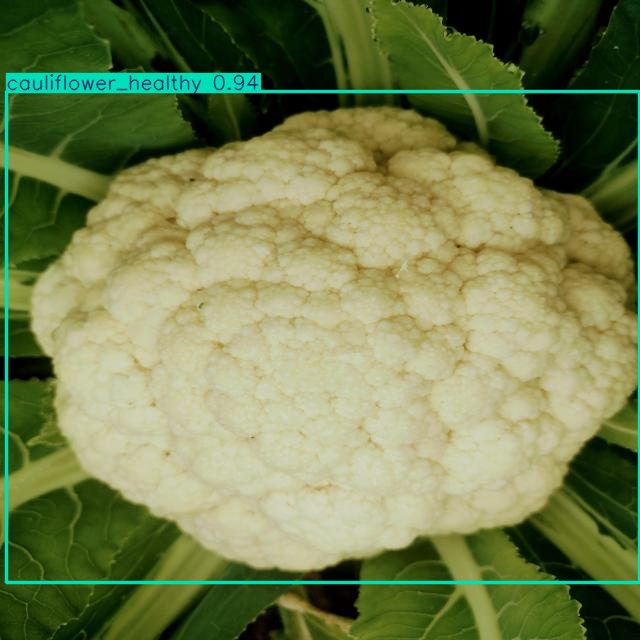
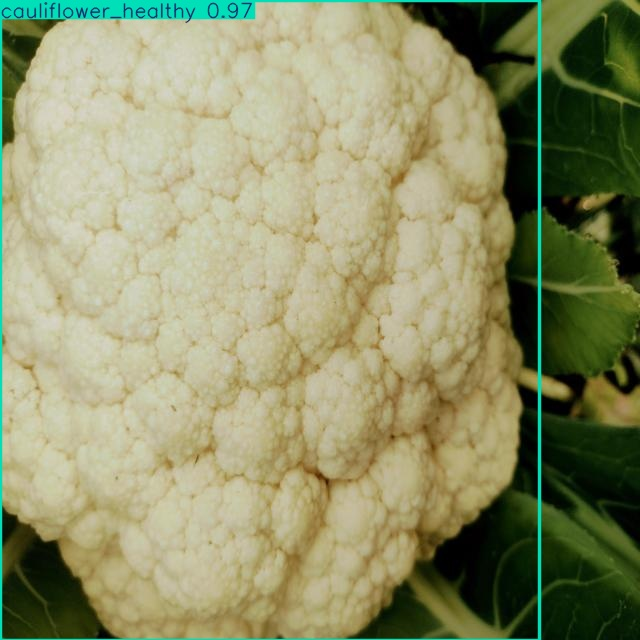
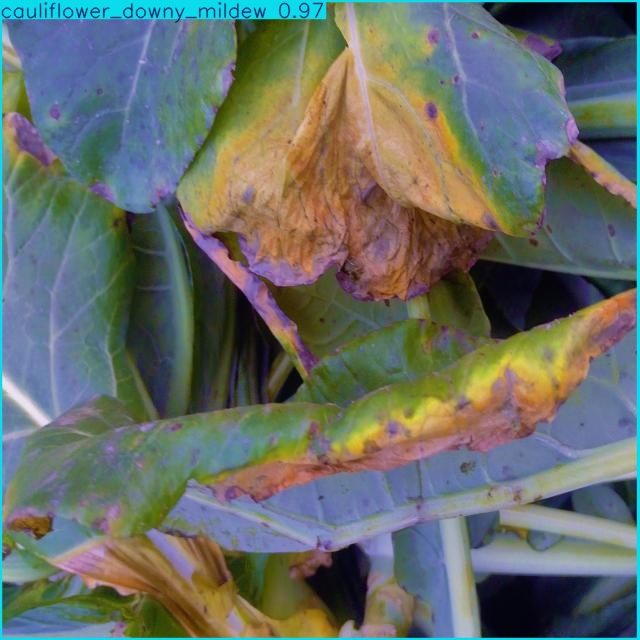
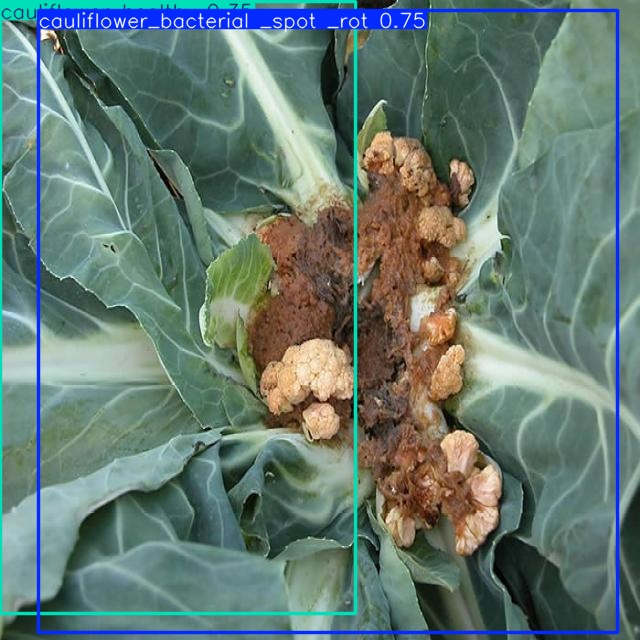
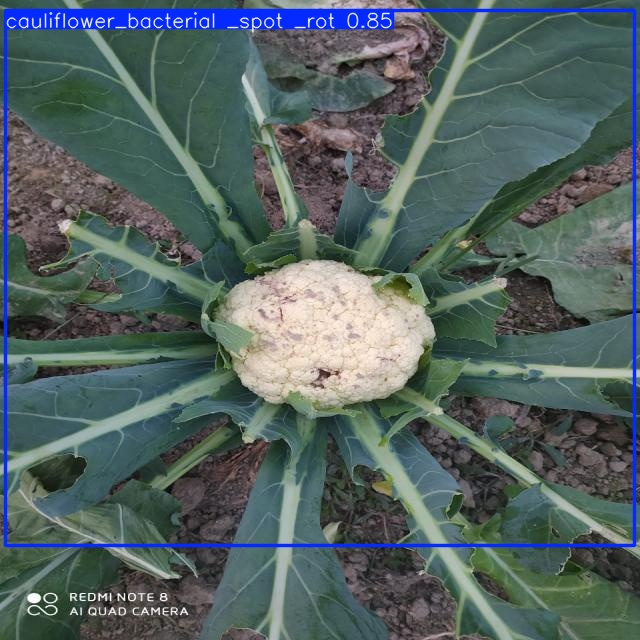
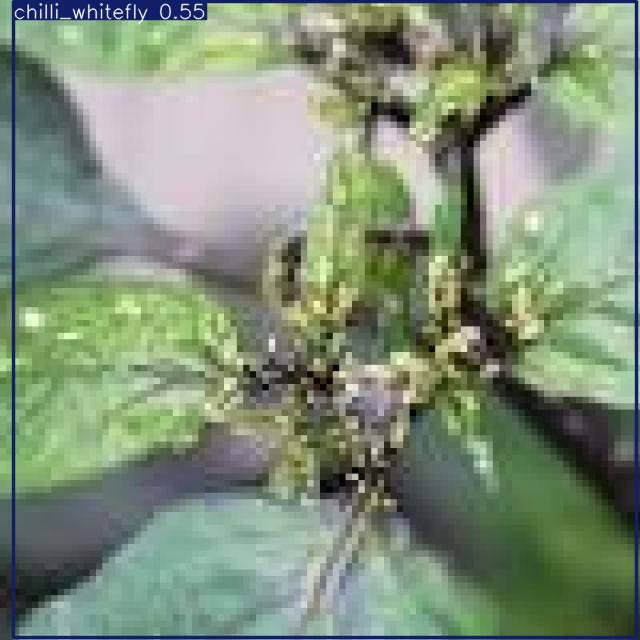
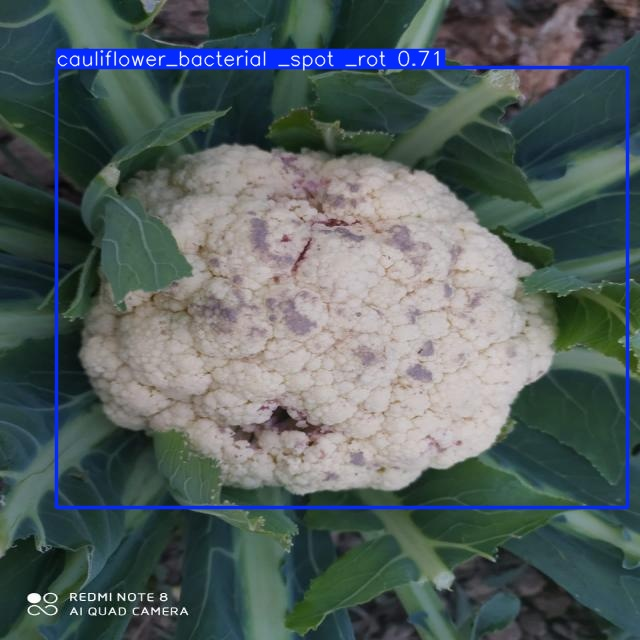
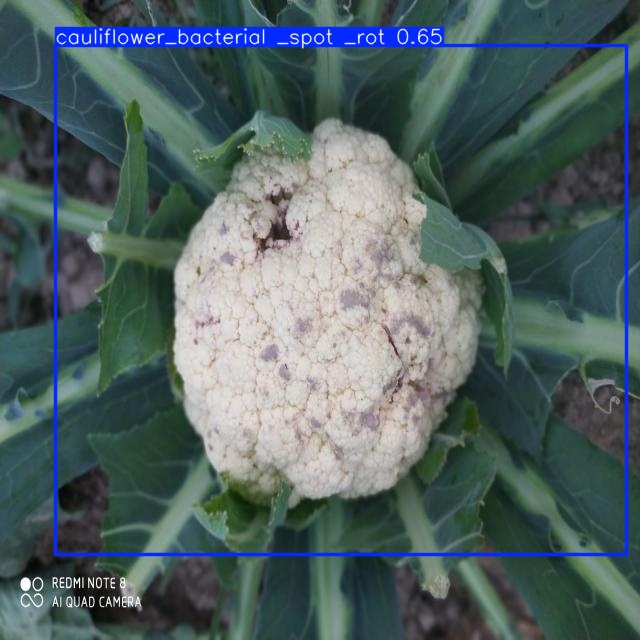
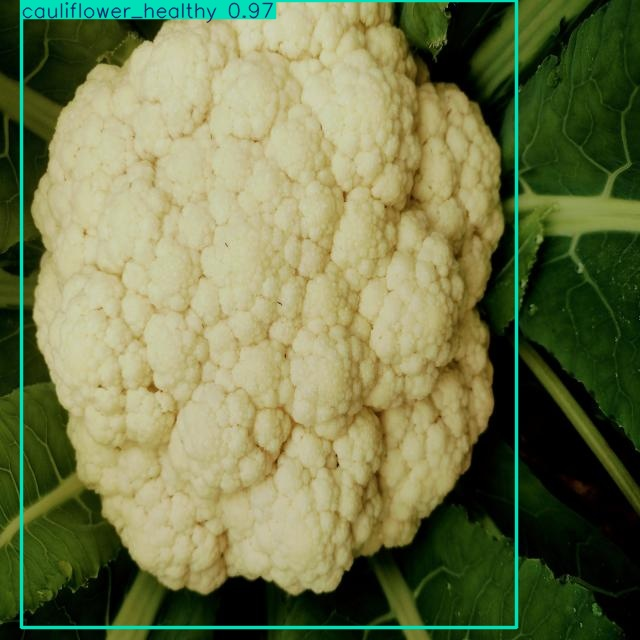
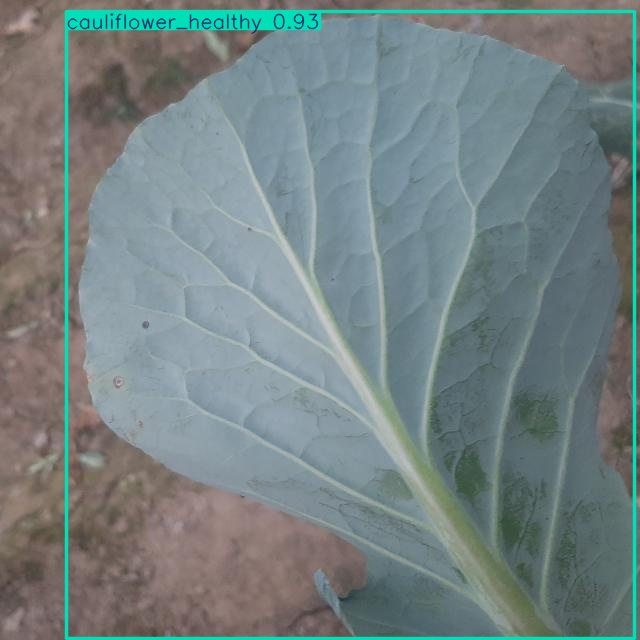
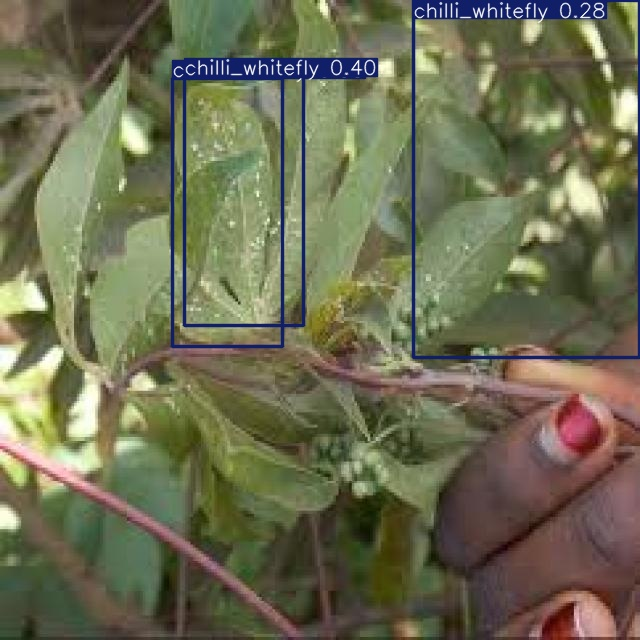

In [10]:
from IPython.display import display, HTML
import os
import base64

folder = "/kaggle/working/runs/detect/predict"
images = os.listdir(folder)[:12]

html = ""

for img in images:
    path = os.path.join(folder, img)
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    html += f'<img src="data:image/jpeg;base64,{data}" width="300" style="margin:5px;">'

display(HTML(html))

In [11]:
model.val()

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 115.5±28.8 MB/s, size: 51.4 KB)
val: Scanning /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/valid/labels... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 715.4it/s 0.2s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/nandini004aikmckmvji/minority-class-dataset/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.6it/s 2.5s
                   all        141        187      0.845      0.706      0.743      0.558
cauliflower_bacterial _spot _rot         34         34      0.985          1      0.995      0.754
cauliflower_downy_mildew         34         42      0.965      0.833      0.852      0.704
cauliflower_downy_mildew         13         27      0.822      0.514      0.604      0.296
   cauliflower_healthy   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e869d34b1d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

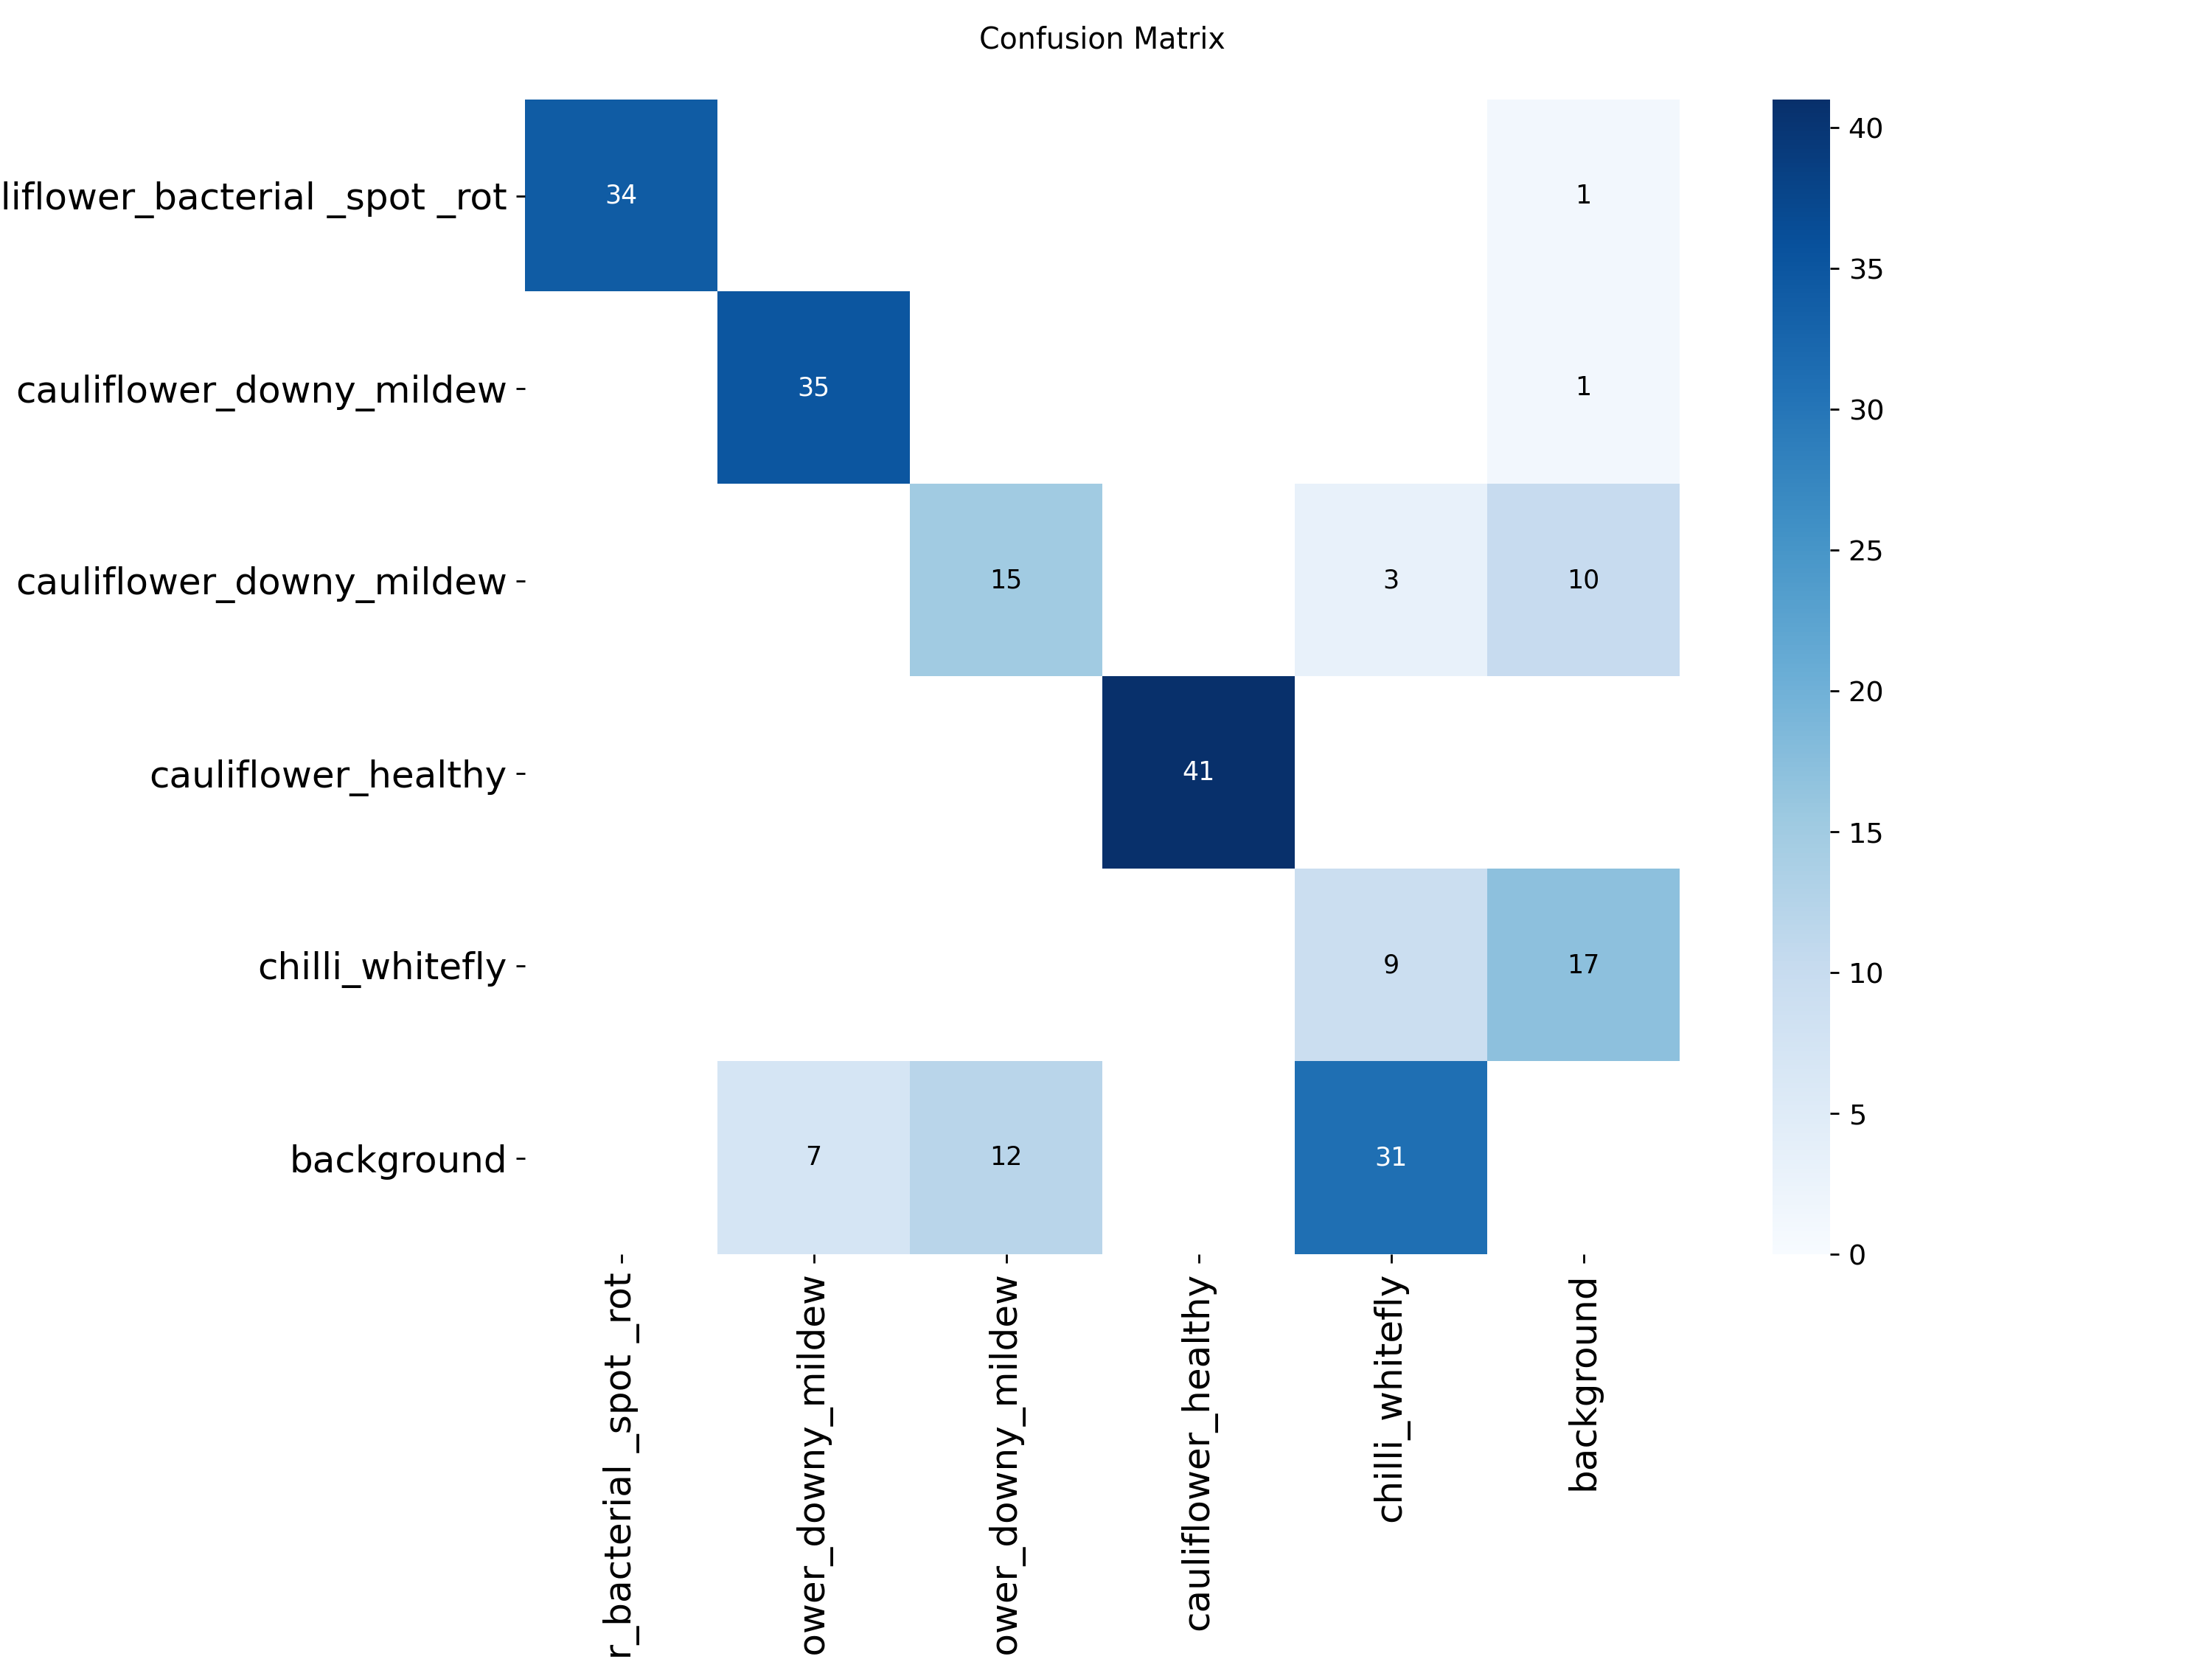

In [12]:
from IPython.display import Image, display

display(Image("/kaggle/working/runs/detect/plant_disease_minority/confusion_matrix.png"))

In [13]:
!zip -r plant_disease_majority.zip /kaggle/working/runs/detect/plant_disease_minority

  adding: kaggle/working/runs/detect/plant_disease_minority/ (stored 0%)
  adding: kaggle/working/runs/detect/plant_disease_minority/BoxR_curve.png (deflated 10%)
  adding: kaggle/working/runs/detect/plant_disease_minority/results.csv (deflated 61%)
  adding: kaggle/working/runs/detect/plant_disease_minority/val_batch2_pred.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/plant_disease_minority/val_batch2_labels.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/plant_disease_minority/train_batch1241.jpg (deflated 3%)
  adding: kaggle/working/runs/detect/plant_disease_minority/results.png (deflated 6%)
  adding: kaggle/working/runs/detect/plant_disease_minority/confusion_matrix.png (deflated 24%)
  adding: kaggle/working/runs/detect/plant_disease_minority/val_batch1_labels.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/plant_disease_minority/labels.jpg (deflated 35%)
  adding: kaggle/working/runs/detect/plant_disease_minority/train_batch1.jpg (deflated 2%)
  adding: k

In [14]:
from IPython.display import FileLink
FileLink('/kaggle/working/plant_disease_minority.zip')

/kaggle/working/plant_disease_minority.zip